In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import pandas as pd
import requests
import zipfile
import io
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def get_historical_gdelt_robust(start_date, end_date, country_fips, cameo_codes):
    """
    Extracts, filters, and aggregates GDELT 1.0 data on a weekly basis for a specific country.
    """
    cameo_codes = [str(code) for code in cameo_codes]
    dates = pd.date_range(start=start_date, end=end_date, freq='MS')
    all_data = []

    print(f"Extracting Historical GDELT for {country_fips}...")
    
    for dt in tqdm(dates):
        month_str = dt.strftime("%Y%m")
        url = f"http://data.gdeltproject.org/events/{month_str}.zip"
        
        try:
            r = requests.get(url, timeout=60)
            if r.status_code == 200:
                with zipfile.ZipFile(io.BytesIO(r.content)) as z:
                    # Dynamically find whatever file is in the zip
                    internal_file_name = z.namelist()[0] 
                    
                    with z.open(internal_file_name) as f:
                        df = pd.read_csv(
                            f, sep='\t', header=None, 
                            usecols=[1, 28, 34, 51], 
                            names=['SQLDATE', 'RootCode', 'AvgTone', 'CountryCode'],
                            dtype={'RootCode': str, 'CountryCode': str, 'SQLDATE': str}
                        )
                
                # Filter for target country immediately
                country_df = df[df['CountryCode'] == country_fips].copy()
                country_df['Date'] = pd.to_datetime(country_df['SQLDATE'], format='%Y%m%d')
                
                # Track Total Volume for this country/month to allow normalization
                total_monthly_events = len(country_df)
                
                # Filter for specific CAMEO codes
                filtered = country_df[country_df['RootCode'].isin(cameo_codes)].copy()
                filtered['Total_Country_Volume'] = total_monthly_events
                
                all_data.append(filtered)
                
        except Exception as e:
            print(f"Skipping {month_str} due to error: {e}")

    if not all_data:
        return "No data found. Ensure you are using a valid FIPS code (e.g., 'EG' for Egypt)."

    full_df = pd.concat(all_data)
    
    # Organize into the trend dictionary with WEEKLY aggregation
    final_trends = {}
    for code in cameo_codes:
        subset = full_df[full_df['RootCode'] == code].set_index('Date')
        
        # Weekly aggregation ('W' defaults to Sundays)
        trend = subset.resample('W').agg({
            'RootCode': 'count',
            'AvgTone': 'mean',
            'Total_Country_Volume': 'mean' 
        }).rename(columns={'RootCode': 'Sampled_Volume', 'AvgTone': 'Average_Tone'})
        
        # Handle empty weeks so the plot line doesn't break
        trend['Sampled_Volume'] = trend['Sampled_Volume'].fillna(0)
        trend['Average_Tone'] = trend['Average_Tone'].ffill() 
        
        # Calculate Salience Score
        trend['Salience_Score'] = (trend['Sampled_Volume'] / trend['Total_Country_Volume']) * 100
        final_trends[code] = trend
        
    return final_trends


def plot_gdelt_trends(trends, target_country_name):
    """
    Takes the weekly dictionary generated by get_historical_gdelt_robust and plots the Salience Scores.
    """
    if isinstance(trends, str):
        print(trends) # Catch and print the error message if no data was found
        return

    plt.figure(figsize=(14, 6))

    # Loop through dictionary and plot each CAMEO code
    for code, df_trend in trends.items():
        plt.plot(
            df_trend.index, 
            df_trend['Salience_Score'], 
            label=f'CAMEO: {code}', 
            linewidth=2
        )

    # Formatting
    plt.title(f'Weekly Salience of GDELT Events in {target_country_name}', fontsize=16, pad=15)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Salience Score (% of Total Volume)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(title='Event Codes', loc='upper left', bbox_to_anchor=(1, 1))

    # Clean date axis layout
    plt.gcf().autofmt_xdate() 
    plt.tight_layout()
    plt.show()

In [8]:
import matplotlib.pyplot as plt

def plot_gdelt_trends(trend_df, event_name="Events"):
    """
    Plots Volume and Average Tone from a GDELT trend DataFrame using dual Y-axes.
    
    Args:
        trend_df (pd.DataFrame): DataFrame containing 'Sampled_Volume' and 'Average_Tone' with a Datetime index.
        event_name (str): The name of the event to display in the title.
    """
    # Check if dataframe is empty to prevent plotting errors
    if trend_df is None or trend_df.empty:
        print(f"No data available to plot for {event_name}.")
        return

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # --- Primary Axis: Event Volume ---
    color1 = 'tab:blue'
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Sampled Volume', color=color1, fontweight='bold')
    ax1.plot(trend_df.index, trend_df['Sampled_Volume'], marker='o', color=color1, label='Volume')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, linestyle='--', alpha=0.6)

    # --- Secondary Axis: Average Tone ---
    ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
    color2 = 'tab:orange'
    ax2.set_ylabel('Average Tone', color=color2, fontweight='bold')
    ax2.plot(trend_df.index, trend_df['Average_Tone'], marker='x', color=color2, label='Tone')
    ax2.tick_params(axis='y', labelcolor=color2)
    
    # Optional: Add a horizontal line at 0 for Tone to easily see positive/negative sentiment
    ax2.axhline(0, color='gray', linestyle=':', alpha=0.8)

    # --- Formatting ---
    plt.title(f'Weekly Sampled Volume and Average Tone: {event_name} (2019)', fontsize=14)
    
    # Combine legends from both axes
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

    fig.tight_layout()  # Ensures labels don't get cut off
    plt.show()

In [ ]:
# Short test window: The height of the Egyptian Revolution
TEST_START = "2008-01-01"
TEST_END = "2012-12-31"
COUNTRY = "EG" 
CODES = ['14', '01', '10']

# This should only take about 2-3 minutes on the RCAC cluster
trends_dict = get_historical_gdelt_robust(TEST_START, TEST_END, COUNTRY, CODES)

Extracting Historical GDELT for EG...


  0%|          | 0/36 [00:00<?, ?it/s]

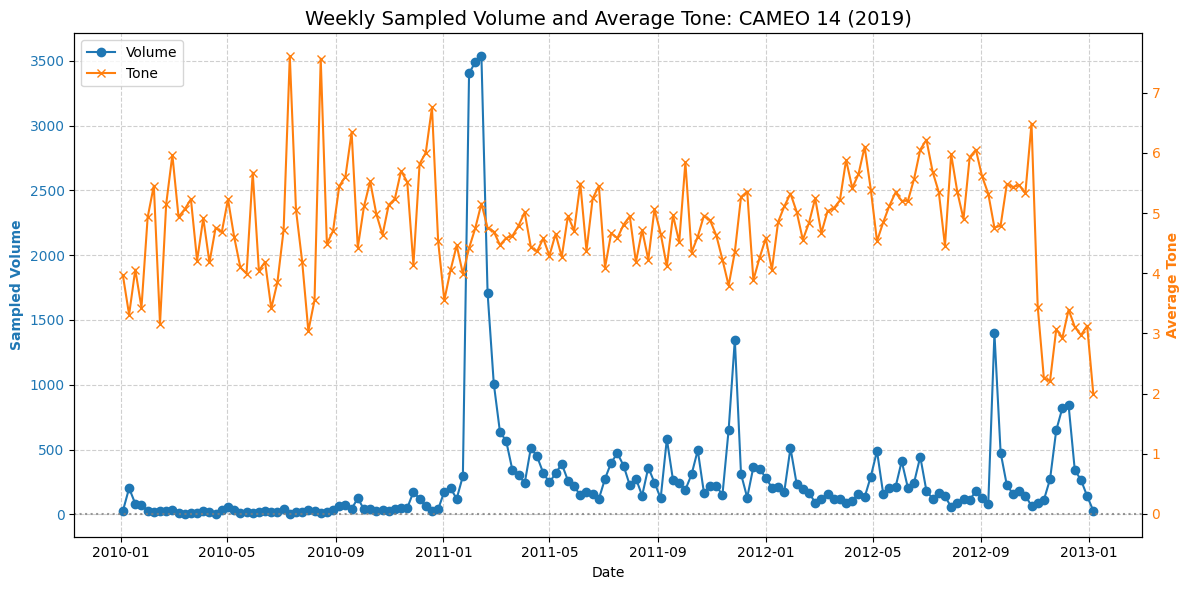

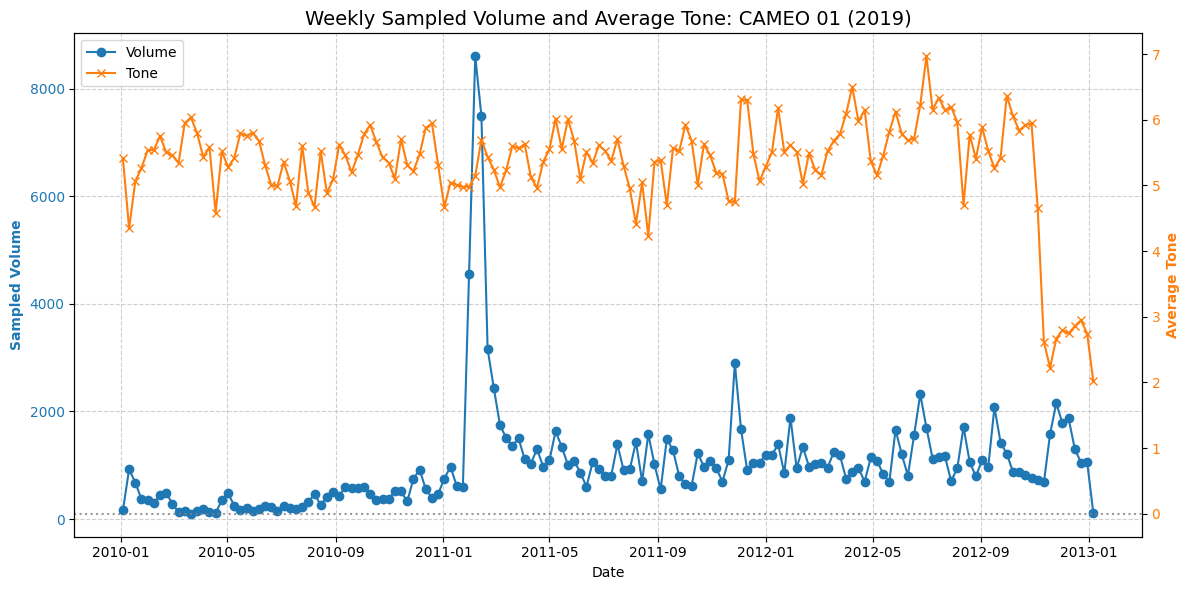

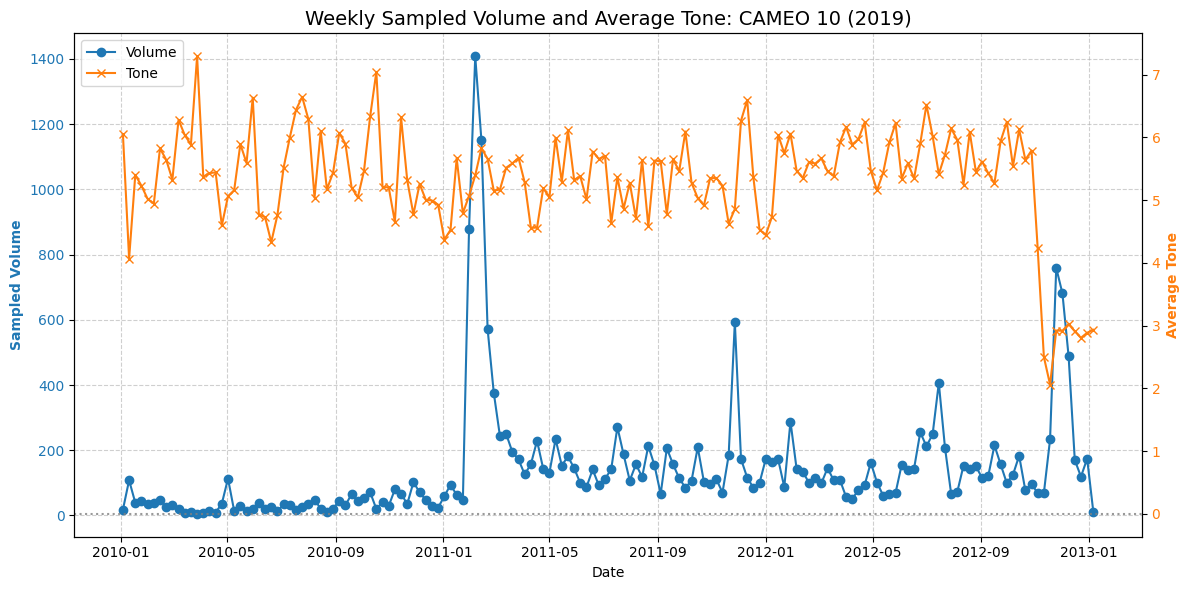

In [10]:
for code, df in trends_dict.items():
    event_name = f"CAMEO {code}"
    plot_gdelt_trends(df, event_name=event_name)